In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import sympy as sp

 - https://www.wolframalpha.com/input?i=solve+%281-u%29+*+x+-+n*u*ln%28%28n-x%29%2Fn%29+%3D+k+*+t+for+x

In [12]:
t, x, k1, k2, n = sp.symbols("t x k1 k2 n")

In [16]:
h1 = (1 - k2) * x + n * k2 * sp.ln((n - x) / x)
h2 = k1 * t

In [20]:
#sp.solve(sp.Eq(h1, h2), x)

In [24]:
R = 8.31446261815324  # J/mol.K
T0 = 292.05           # K
p0 = 101600           # Pa
V = 190e-3            # L of Isopropanol
m = 2.7677            # g of Raney Nickel
rho = 785             # g/L
M = 60.1              # g/mol
n0 = rho * V / M      # mol

In [25]:
k1, k2 = [9.03185361e-06, 7.80055898e+01]

In [26]:
t = np.linspace(0, 8000, 250)

In [29]:
def xi(t, k1, k2, n):
    return np.real((n / (k2 - 1.)) * (k2 * special.lambertw(- (1. / k2) * np.exp(- k1 * t / (n * k2) + 1. / k2 - 1.) * (k2 - 1.)) + k2 - 1.))

In [45]:
def xi2(t, k1, k2, n):
    return np.real(n0 * (1 - k2 / (1 - k2) * special.lambertw((1 - k2) / k2 * np.exp(- k1 * t / (n0 * k2) + (1 - k2) / k2))))

$$
\begin{align}
(1 - k_2) \xi - n_0 k_2 \ln\left(\frac{n_0 - \xi}{n_0}\right) &= k_1 t \\
\Leftrightarrow -\frac{1 - k_2}{n_0 k_2}\xi + \ln\left(\frac{n_0 - \xi}{n_0}\right) &= - \frac{k_1 t}{n_0 k_2} \\
\Leftrightarrow -\frac{1 - k_2}{n_0 k_2}\xi + \frac{1 - k_2}{k_2} + \ln\left(\frac{n_0 - \xi}{n_0}\right) &= - \frac{k_1 t}{n_0 k_2} + \frac{1 - k_2}{k_2} \\
\Leftrightarrow \frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0} + \ln\left(\frac{n_0 - \xi}{n_0}\right) &= - \frac{k_1 t}{n_0 k_2} + \frac{1 - k_2}{k_2} \\
\Leftrightarrow \exp\left(\frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0}\right)\frac{n_0 - \xi}{n_0} &= \exp\left(- \frac{k_1 t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right) \\
\Leftrightarrow \exp\left(\frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0}\right)\frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0} &= \frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right) \\
\Leftrightarrow \frac{1 - k_2}{k_2}\frac{n_0 - \xi}{n_0} &= W_0\left[\frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right)\right] \\
\Leftrightarrow \frac{n_0 - \xi}{n_0} &= \frac{k_2}{1 - k_2}W_0\left[\frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right)\right] \\
\Leftrightarrow \xi &= n_0 \left( 1 - \frac{k_2}{1 - k_2}W_0\left[\frac{1 - k_2}{k_2}\exp\left(- \frac{k_1 t}{n_0 k_2} + \frac{1 - k_2}{k_2}\right)\right] \right) \\
\end{align}
$$

In [46]:
x = xi(t, k1, k2, n0)
x2 = xi2(t, k1, k2, n0)

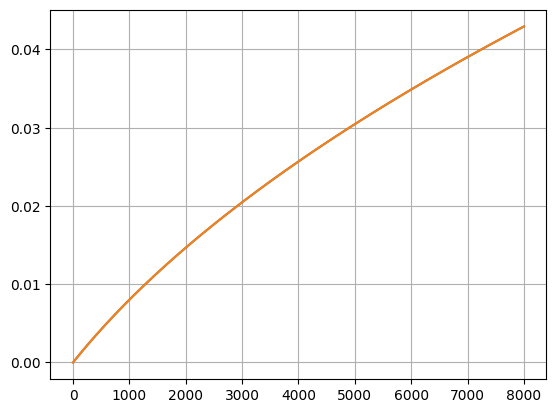

In [47]:
fig, axe = plt.subplots()
axe.plot(t, x)
axe.plot(t, x2)
axe.grid()